In [45]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras as keras

DATA_DIR = Path(".")  

spectrums = np.load(DATA_DIR / "spectrums.npy")
params = pd.read_csv(DATA_DIR / "FM_Parameter_Table.csv")
aux = pd.read_csv(DATA_DIR / "AuxillaryTable.csv")

# spectrums shape: (examples, wavelengths, 4)
wavelength_grid = spectrums[:, :, 0]
spectrum = spectrums[:, :, 1]
uncertainty = spectrums[:, :, 2]
bin_width = spectrums[:, :, 3]


# Labels: inspect columns first, then choose target columns
print(params.columns)
print(aux.columns)
print(spectrums.shape, params.shape, aux.shape)

Index(['Unnamed: 0', 'planet_ID', 'planet_radius', 'planet_temp', 'log_H2O',
       'log_CO2', 'log_CO', 'log_CH4', 'log_NH3'],
      dtype='object')
Index(['planet_ID', 'star_distance', 'star_mass_kg', 'star_radius_m',
       'star_temperature', 'planet_mass_kg', 'planet_orbital_period',
       'planet_distance', 'planet_surface_gravity'],
      dtype='object')
(41423, 52, 4) (41423, 9) (41423, 9)


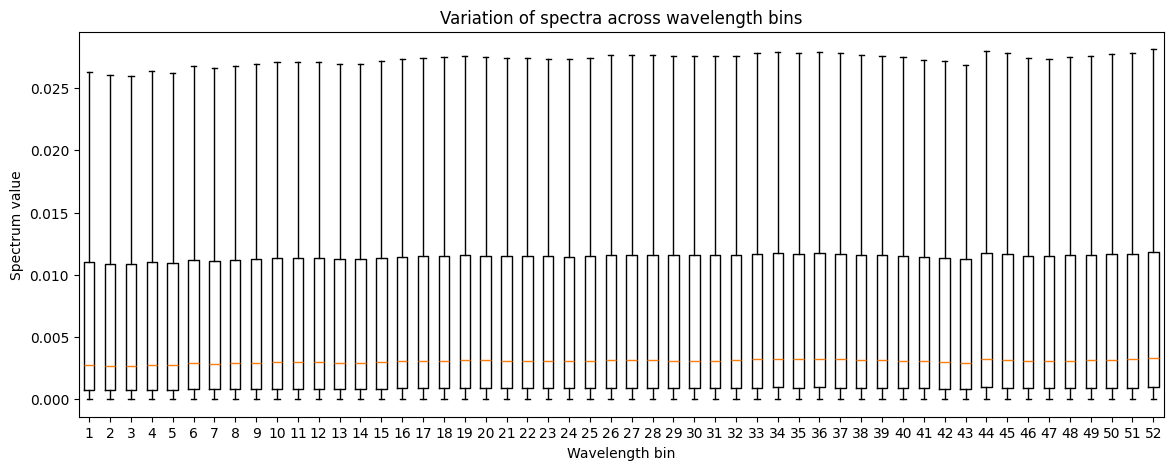

In [46]:
import matplotlib.pyplot as plt

X = spectrums[:, :, 1]   # shape: (41423, 52)

plt.figure(figsize=(14, 5))
plt.boxplot(X, showfliers=False)
plt.xlabel("Wavelength bin")
plt.ylabel("Spectrum value")
plt.title("Variation of spectra across wavelength bins")
plt.show()

In [47]:
from sklearn.model_selection import train_test_split
# Use the spectrum values as input features
target_cols = ["log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3", "planet_radius", "planet_temp"]

X = spectrums[:, :, 1].astype("float32")
y = params[target_cols].values.astype("float32")

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.20, random_state=42)

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)
print(x_train.mean())
#normalize the input features
from sklearn.preprocessing import StandardScaler    
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)
y_train_scaled = scaler.fit_transform(y_train)
y_val_scaled = scaler.transform(y_val)
y_test_scaled = scaler.transform(y_test)
print(x_train_scaled.mean(), x_train_scaled.std())

(29824, 52) (29824, 7)
(7456, 52) (7456, 7)
(4143, 52) (4143, 7)
0.008264877
2.4597492e-11 0.99999994


In [48]:
model = keras.Sequential([
    keras.layers.Input(shape=(52,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(7)
])

lr_callback = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    x_train_scaled,
    y_train_scaled,
    validation_data=(x_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=64,
    callbacks=[lr_callback]
)

Epoch 1/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8969 - mae: 0.7831 - val_loss: 0.8020 - val_mae: 0.7302 - learning_rate: 0.0010
Epoch 2/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7832 - mae: 0.7171 - val_loss: 0.7440 - val_mae: 0.6977 - learning_rate: 0.0010
Epoch 3/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7271 - mae: 0.6848 - val_loss: 0.7086 - val_mae: 0.6735 - learning_rate: 0.0010
Epoch 4/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6794 - mae: 0.6567 - val_loss: 0.6182 - val_mae: 0.6268 - learning_rate: 0.0010
Epoch 5/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6247 - mae: 0.6229 - val_loss: 0.6226 - val_mae: 0.6137 - learning_rate: 0.0010
Epoch 6/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5832 - mae: 0.5973 - val_loss: 0.5559 - val_mae: 0.5840 - learning_rate: 0.0010
Epoch 7/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5563 - mae: 0.5803 - val_loss: 0.5106 - val_mae: 0.5483 - learning_rate: 0.0010

In [49]:
test_loss, test_mae = model.evaluate(x_test_scaled, y_test_scaled)
print(f"Test MAE: {test_mae:.4f}")
print(f"Test MSE: {test_loss:.4f}")
y_pred = model.predict(x_test_scaled)
print(y_pred[:5])

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2060 - mae: 0.3189  
Test MAE: 0.3169
Test MSE: 0.2023
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[-0.34485945  1.6407646  -0.43223166  0.8993844  -0.26534182  0.63846326
   0.09501239]
 [-0.07809494 -1.2240437  -0.8212573  -0.9282861   1.3180802   1.5341413
  -0.37856627]
 [ 0.5024968   1.0122613  -0.2221773   1.3824284  -0.46553025 -1.1107323
   0.42852113]
 [ 0.8983288  -0.5063733   0.03776222 -0.28511775  0.98270166  0.49157047
   0.01135635]
 [-0.6410425   1.3344488  -0.65328103  1.1641797  -0.1056378  -0.42719278
  -0.27916932]]


130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step


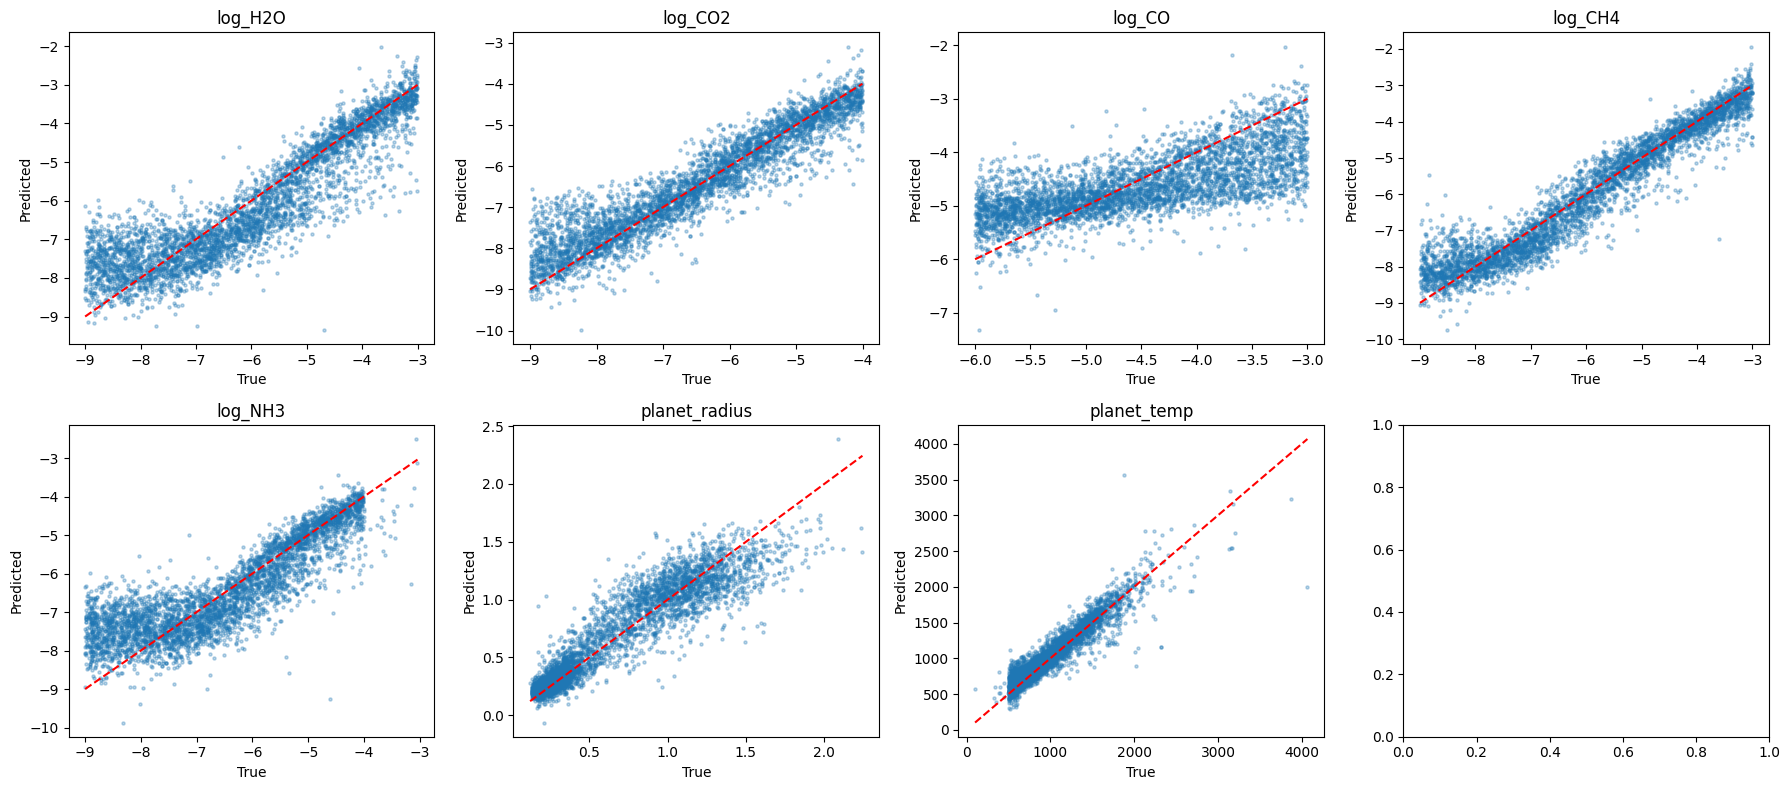

In [50]:
y_pred_scaled = model.predict(x_test_scaled)
y_pred = scaler.inverse_transform(y_pred_scaled)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for i, col in enumerate(target_cols):
    axes[i].scatter(y_test[:, i], y_pred[:, i], s=5, alpha=0.3)
    axes[i].plot(
        [y_test[:, i].min(), y_test[:, i].max()],
        [y_test[:, i].min(), y_test[:, i].max()],
        "r--"
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("True")
    axes[i].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

In [51]:
from sklearn.metrics import mean_absolute_error

for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test_scaled[:, i], y_pred_scaled[:, i])
    print(col, mae)

log_H2O 0.316699355840683
log_CO2 0.2558090090751648
log_CO 0.5747333765029907
log_CH4 0.20696163177490234
log_NH3 0.3743758201599121
planet_radius 0.25672540068626404
planet_temp 0.23266169428825378


In [52]:
baseline_pred_scaled = np.tile(
    y_train_scaled.mean(axis=0),
    (y_test_scaled.shape[0], 1)
)

for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test_scaled[:, i], baseline_pred_scaled[:, i])
    print(col, mae)

log_H2O 0.8606834411621094
log_CO2 0.8605521321296692
log_CO 0.8744441866874695
log_CH4 0.8760483264923096
log_NH3 0.862828254699707
planet_radius 0.8789140582084656
planet_temp 0.7764521837234497


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target_cols = [
    "planet_radius", "planet_temp",
    "log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"
]

# Spectrum input: 52 wavelength bins
X_spectrum = spectrums[:, :, 1].astype("float32")

# Extra auxiliary input: orbital distance
aux_cols = ["planet_distance"]

# Match aux rows to params rows by planet_ID
aux_ordered = aux.set_index("planet_ID").loc[params["planet_ID"], aux_cols]
X_aux = aux_ordered.values.astype("float32")

# Final input: 52 spectrum bins + 1 auxiliary feature
X = np.hstack([X_spectrum, X_aux])

y = params[target_cols].values.astype("float32")

# Split
x_train, x_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=42
)

# Standardize X
x_scaler = StandardScaler()

x_train_scaled = x_scaler.fit_transform(x_train)
x_val_scaled = x_scaler.transform(x_val)
x_test_scaled = x_scaler.transform(x_test)

# Standardize y
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train)
y_val_scaled = y_scaler.transform(y_val)
y_test_scaled = y_scaler.transform(y_test)

In [54]:
model = keras.Sequential([
    keras.layers.Input(shape=(x_train_scaled.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(len(target_cols))
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    x_train_scaled,
    y_train_scaled,
    validation_data=(x_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=64,
    callbacks=[lr_callback]
)

Epoch 1/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8559 - mae: 0.7578 - val_loss: 0.7761 - val_mae: 0.7102 - learning_rate: 0.0010
Epoch 2/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7643 - mae: 0.7045 - val_loss: 0.7242 - val_mae: 0.6837 - learning_rate: 0.0010
Epoch 3/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7098 - mae: 0.6726 - val_loss: 0.6809 - val_mae: 0.6525 - learning_rate: 0.0010
Epoch 4/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6704 - mae: 0.6476 - val_loss: 0.6376 - val_mae: 0.6277 - learning_rate: 0.0010
Epoch 5/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6300 - mae: 0.6248 - val_loss: 0.6798 - val_mae: 0.6469 - learning_rate: 0.0010
Epoch 6/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6055 - mae: 0.6101 - val_loss: 0.5698 - val_mae: 0.5876 - learning_rate: 0.0010
Epoch 7/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5779 - mae: 0.5922 - val_loss: 0.5785 - val_mae: 0.5854 - learning_rate: 0.0010

In [55]:
y_pred_scaled = model.predict(x_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step


195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step


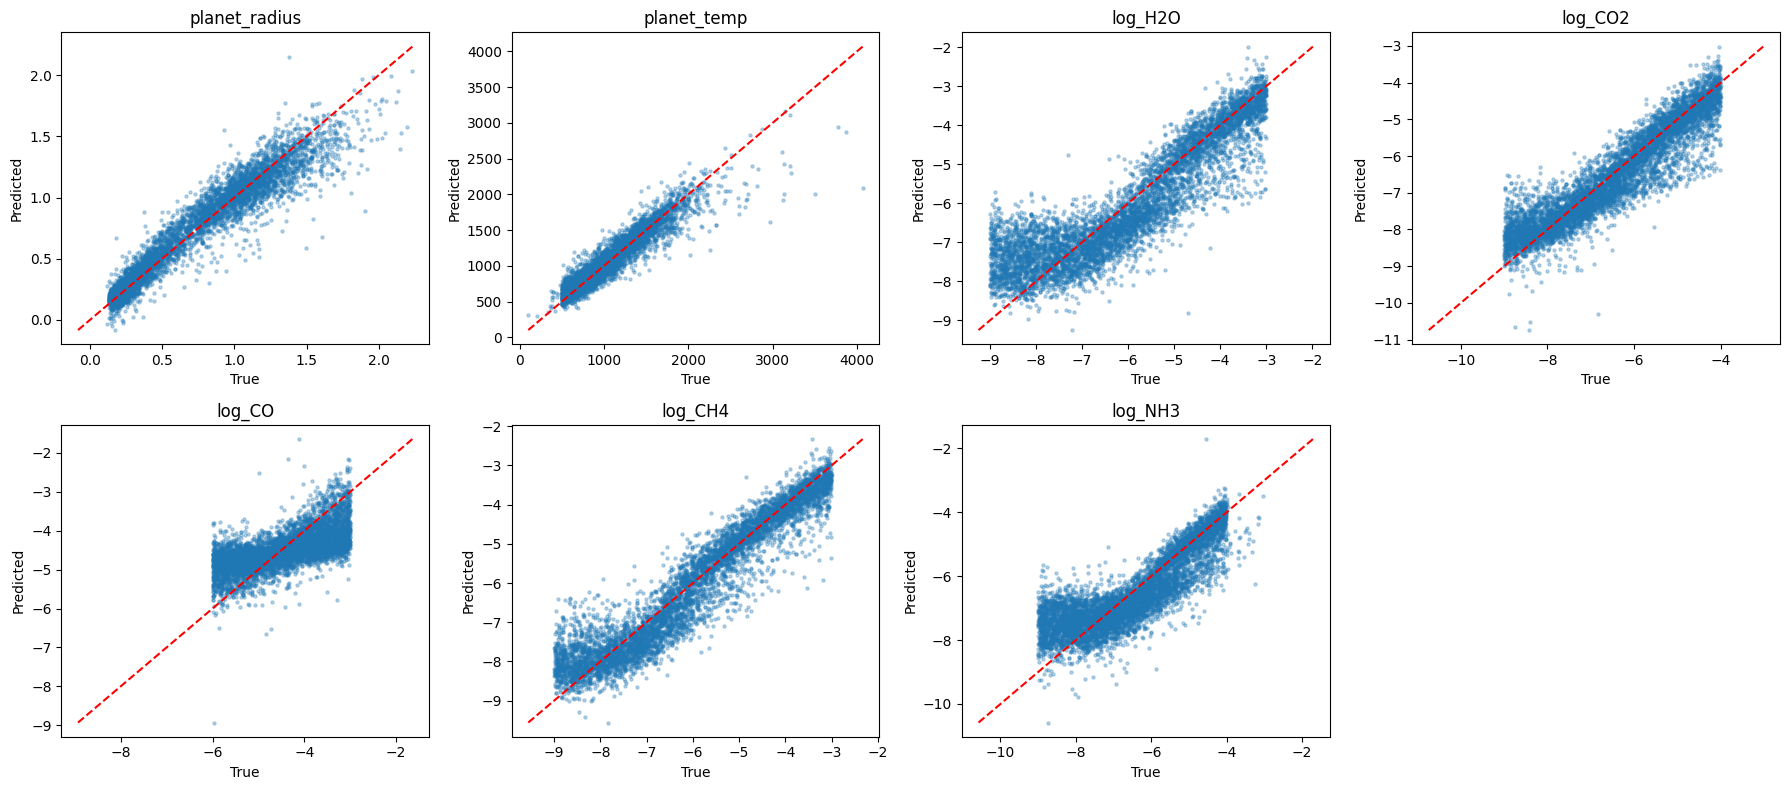

In [56]:
y_pred_scaled = model.predict(x_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(target_cols):
    axes[i].scatter(y_test[:, i], y_pred[:, i], s=5, alpha=0.3)
    
    min_val = min(y_test[:, i].min(), y_pred[:, i].min())
    max_val = max(y_test[:, i].max(), y_pred[:, i].max())
    
    axes[i].plot([min_val, max_val], [min_val, max_val], "r--")
    axes[i].set_title(col)
    axes[i].set_xlabel("True")
    axes[i].set_ylabel("Predicted")

# remove unused 8th subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()